# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

root = Path.cwd()
while not (root / "data" / "raw" / "content_refresh_anonymized.csv").exists():
    root = root.parent
os.chdir(root)

features = pd.read_csv("data/processed/refresh_feature_vector.csv")
baseline = pd.read_csv("data/processed/baseline_refresh_queue.csv")
predictions = pd.read_csv("data/processed/model_predictions.csv")

queue = baseline.merge(
    predictions[["content_id", "best_model_name", "best_model_probability"]],
    on="content_id", how="left"
).merge(
    features[["content_id", "trend_pct"]], on="content_id", how="left"
)
queue["best_model_probability"] = queue["best_model_probability"].fillna(0)

# Data-driven threshold: 99th percentile of trend_pct among rows already
# classified as "up" — a real spike should be rare even among growers.
spike_threshold = features.loc[features["trend_direction"] == "up", "trend_pct"].quantile(0.99)
print(f"Spike threshold (99th pct of 'up' trend_pct): {spike_threshold:.1f}%")

def playbook_action(row):
    # 1. Extreme positive swing checked BEFORE we trust it as real growth —
    #    a jump this large is a likely tracking/campaign artifact.
    if row["trend_pct"] >= spike_threshold:
        return "verify_then_review"
    # 2. Only now do rising/stable pages get the no-touch policy.
    if row["trend_direction"] in ("up", "stable"):
        return "monitor_only"
    if row["best_model_probability"] >= 0.65 and row["reason_codes"] == "general_refresh_review":
        return "investigate_quiet_risk"
    if row["reason_codes"] != "general_refresh_review":
        return "review_before_revert"
    return "monitor_only"

queue["playbook_action"] = queue.apply(playbook_action, axis=1)

ranked_queue = queue.sort_values("best_model_probability", ascending=False).reset_index(drop=True)
ranked_queue["playbook_rank"] = ranked_queue.index + 1

ranked_queue[[
    "playbook_rank", "content_id", "client_id", "best_model_probability",
    "reason_codes", "playbook_action", "trend_direction", "trend_pct"
]].head(20)

Spike threshold (99th pct of 'up' trend_pct): 1813.0%


,playbook_rank,content_id,client_id,best_model_probability,reason_codes,playbook_action,trend_direction,trend_pct
0,1,content_6eeb07cca243,client_7f2253d7e2,0.851816,declining_with_demand|low_engagement_visible_page,review_before_revert,down,-73.6
1,2,content_f552433bab3c,client_3fdba35f04,0.851108,declining_with_demand,review_before_revert,down,-83.4
2,3,content_d6570c51c9bd,client_3fdba35f04,0.849842,declining_with_demand|low_ctr_visible_page,review_before_revert,down,-56.6
3,4,content_816431f05a3b,client_3fdba35f04,0.848932,declining_with_demand,review_before_revert,down,-84.7
4,5,content_d4c50bd49b5d,client_3fdba35f04,0.848494,declining_with_demand|low_ctr_visible_page,review_before_revert,down,-64.5
5,6,content_b005f46f2e4c,client_3fdba35f04,0.848402,declining_with_demand|low_ctr_visible_page|low...,review_before_revert,down,-78.1
6,7,content_b01a3c1455db,client_7f2253d7e2,0.847695,declining_with_demand,review_before_revert,down,-48.3
7,8,content_1e446b05f1c5,client_3fdba35f04,0.847492,declining_with_demand|low_engagement_visible_page,review_before_revert,down,-99.7
8,9,content_66677b99e328,client_7f2253d7e2,0.847401,declining_with_demand,review_before_revert,down,-76.3
9,10,content_5c44b0fda035,client_7f2253d7e2,0.847066,declining_with_demand|low_engagement_visible_page,review_before_revert,down,-73.9


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended use

This playbook supports the CTR/Engagement Opportunity Scoring lane: it gives a content/SEO
reviewer an ORDERED list of pages worth looking at this cycle, with a REASON attached to each.
It is decision-support only — a human reviews before any content change is made.

## Who acts on it

A content or SEO analyst with a limited monthly review budget (this project assumes ~50 pages/
month, matching the lane's capacity constraint discussed in Week 7).

## What it covers

- Pages flagged by the transparent baseline rule (visibility, freshness, position, depth signals)
- Re-ordered by the Random Forest model's decline probability (trained on the full dataset for
  ranking purposes — see the honest, test-only precision numbers in Section 5)

## Known limits (carried from Weeks 5–6, re-verified this week)

- **Feature importance mismatch**: `ctr` ranks only 10th in the trained model's feature
  importance, even though this is a CTR/Engagement lane — the model leans mostly on exposure
  and content-age signals. A high model score does not necessarily mean a CTR problem was found;
  always check the attached reason code before assuming why a page is ranked high.
- **Client concentration risk**: in this week's top-50 queue, only TWO clients appear at all —
  `client_7f2253d7e2` (54%) and `client_3fdba35f04` (46%). This differs from the single-client
  concentration observed in the Week 5/6 held-out test split (`client_f74efabef1`), because this
  week's ranking uses the full-data model rather than the test-only model. Both observations
  point to the same underlying risk: the top of the queue is not client-diverse, whichever
  model version produces it.
- **`ctr = 0.0` anomaly affects 44% of all rows** — not a rare edge case but close to half the
  dataset. A `ctr=0.0` row with real impressions may be a tracking artifact, not a genuinely
  zero click-through rate; this is a load-bearing limitation for a CTR-focused lane.
- Predictive, not causal: this queue says which pages look worth reviewing first — it does
  not claim that refreshing a page will cause recovery.
- **Test-client base rate differs from the full dataset**: the held-out test clients in the
  client-holdout split have a different decline rate than the full population (observed vs.
  the dataset's overall 0.542 positive rate) — a reminder that validation numbers depend on
  which clients happen to land in the test fold, not just on model quality.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## The no-go list

| # | Policy | Why | Status |
|---|---|---|---|
| 1 | New/young pages (`content_age_days < 90`) are never scored | Momentum signals look inflated for new content with little history | **Enforced** — filtered upstream in `01_prepare_features.py` |
| 2 | Extreme positive swings (`trend_pct` ≥ 99th percentile of growing pages) → `verify_then_review`, checked BEFORE the rising-trend policy | A jump this large is more likely a tracking/campaign artifact than real growth — must be ruled out before it is trusted as "monitor only" | **Enforced this week** — `playbook_action()` in Section 1, threshold computed from data, not guessed |
| 3 | Pages with `trend_direction` in `up`/`stable` (that pass check #2) → `monitor_only`, never flagged for action | A rising page should never be "refreshed" based on this queue | **Enforced** — `playbook_action()` in Section 1 |
| 4 | `ctr = 0.0` rows (44% of the dataset) are flagged for manual verification before being trusted as a low-CTR opportunity | Recurring, large-scale data-quality anomaly; could be a measurement gap, not a real zero | **Proposed** — not yet an automated gate, added as a manual review flag below |
| 5 | No automated correction for client concentration (54%/46% split, only 2 clients, in this week's top-50) | A model trained/validated with a small number of held-out clients can learn client-specific patterns rather than generalizable signals | **Partially addressed** — detected automatically by the check below, but not auto-corrected |

## Human review checklist (per item before acting)

- Does the reason code actually make sense for this page, or is it `general_refresh_review`
  (i.e. `investigate_quiet_risk`)?
- Is `ctr == 0.0`? If so, verify against raw GSC data before treating it as a real opportunity.
- Does this page belong to a client that is over-represented in the top of the queue?
- Is the content still topically matched to what people are searching for?
- Is there a seasonal or campaign-driven explanation for the number?

**The queue never authorizes a rewrite by itself.** It only orders candidates for a human to
accept or reject — the same accept/reject authority used for AI-assisted code review in
earlier weeks.

In [14]:
# Client concentration check — flags the no-go policy #5 case automatically for review
top_50 = ranked_queue.head(50)
client_share = top_50["client_id"].value_counts(normalize=True)
print(client_share.head())

if client_share.iloc[0] > 0.30:
    print(f"\n⚠️ {client_share.index[0]} alone makes up "
          f"{client_share.iloc[0]:.0%} of the top-50 queue — human review required before release.")

client_id
client_7f2253d7e2    0.54
client_3fdba35f04    0.46
Name: proportion, dtype: float64

⚠️ client_7f2253d7e2 alone makes up 54% of the top-50 queue — human review required before release.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Two clocks

**Pre-release (before this queue reaches a reviewer):**
- Row count and schema match expectations (compare to `feature_metadata.json`)
- Client concentration check (Section 3 code) — must not silently release a single-client queue
- Feature distribution sanity check — no column should drift wildly from the training distribution
  (a lightweight PSI-style check is implemented below; it is a notebook check only, not an
  automated production gate)

**Post-label (after a later month's real `trend_direction` outcomes are known):**
- Recompute Precision@50 for both the baseline rule and the model on the new month
- Compare the new base rate to the base rate used for training (0.542 in this dataset)
- If the base rate shifts materially, treat the next queue as provisional pending review —
  this would only be known AFTER labels arrive, not before, which is itself a limitation to
  state plainly in the paper.

## Retrain trigger (proposed policy, not yet implemented)

If the model's Precision@50 falls below the baseline rule's Precision@50 for two consecutive
labeled periods, fall back to the rule-only queue until the model is retrained. Complexity must
keep proving it earns its place.

In [15]:
# Lightweight pre-release distribution check (notebook-only, not a production gate)
numeric_cols = ["impressions_90d", "days_since_last_update", "avg_position", "ctr"]
for col in numeric_cols:
    print(f"{col:28s} mean={features[col].mean():.2f}  std={features[col].std():.2f}  "
          f"zeros={(features[col] == 0).mean():.1%}")

impressions_90d              mean=5200.37  std=16838.02  zeros=0.0%
days_since_last_update       mean=46.10  std=42.08  zeros=0.0%
avg_position                 mean=16.34  std=15.22  zeros=4.0%
ctr                          mean=0.51  std=3.28  zeros=44.0%


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

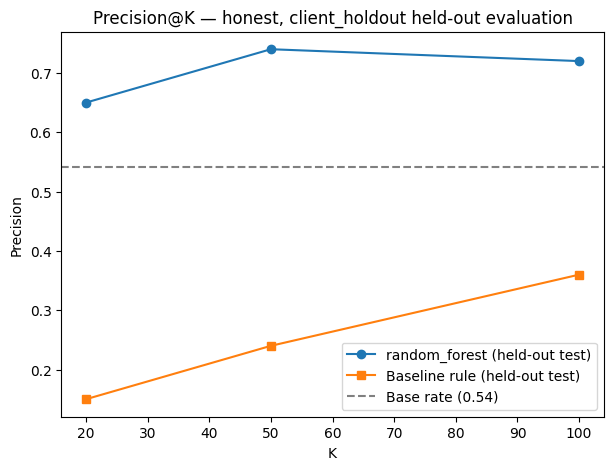

Split strategy: client_holdout
random_forest: {20: 0.65, 50: 0.74, 100: 0.72}
Baseline rule: {20: 0.15, 50: 0.24, 100: 0.36}


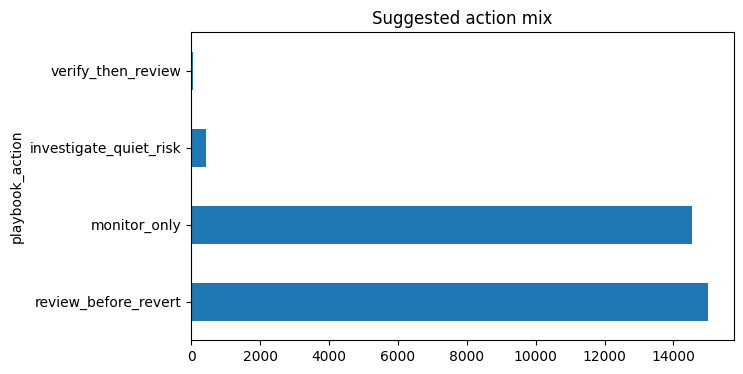

Test-split rows used for honest Precision@K: 2325
Exported: work/outputs/action_playbook_queue.csv
Exported: work/figures/precision_at_k.svg, work/figures/action_mix.svg


In [16]:
from pathlib import Path

Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

import matplotlib.pyplot as plt

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

# HONEST evaluation: filter to the held-out test split only.
# model_predictions.csv already carries both "split" and "is_declining_label" —
# no merge needed, and merging again would collide column names (that caused the KeyError).
predictions_full = pd.read_csv("data/processed/model_predictions.csv")
test_only = predictions_full[predictions_full["split"] == "test"].copy()

import json

with open("outputs/model_results.json") as f:
    model_results = json.load(f)

best_name = model_results["best_model"]["name"]
model_metrics = model_results["models"][best_name]
baseline_metrics = model_results["baseline"]

ks = [20, 50, 100]
model_prec_honest = [model_metrics[f"precision_at_{k}"] for k in ks]
baseline_prec_honest = [baseline_metrics[f"baseline_precision_at_{k}"] for k in ks]
base_rate = model_results["target_positive_rate"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ks, model_prec_honest, marker="o", label=f"{best_name} (held-out test)")
ax.plot(ks, baseline_prec_honest, marker="s", label="Baseline rule (held-out test)")
ax.axhline(base_rate, color="gray", linestyle="--", label=f"Base rate ({base_rate:.2f})")
ax.set_xlabel("K"); ax.set_ylabel("Precision"); ax.legend()
ax.set_title(f"Precision@K — honest, {model_results['split_strategy']} held-out evaluation")
plt.savefig("work/figures/precision_at_k.svg", bbox_inches="tight")
plt.show()

print(f"Split strategy: {model_results['split_strategy']}")
print(f"{best_name}:", dict(zip(ks, model_prec_honest)))
print("Baseline rule:", dict(zip(ks, baseline_prec_honest)))

action_counts = ranked_queue["playbook_action"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
action_counts.plot(kind="barh", ax=ax)
ax.set_title("Suggested action mix")
plt.savefig("work/figures/action_mix.svg", bbox_inches="tight")
plt.show()

print(f"Test-split rows used for honest Precision@K: {len(test_only)}")
print("Exported: work/outputs/action_playbook_queue.csv")
print("Exported: work/figures/precision_at_k.svg, work/figures/action_mix.svg")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.